[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Tue Oct  1 13:03:44 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   47C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.2 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.2/112.6 GB disk)


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [ ]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

100% 5.35M/5.35M [00:00<00:00, 95.9MB/s]
WARNING ⚠️ yolo11n.pt appears to require 'dill', which is not in Ultralytics requirements.
AutoInstall will run now for 'dill' but this feature will be removed in the future.
Recommend fixes are to train a new model using the latest 'ultralytics' package or to run a command with an official Ultralytics model, i.e. 'yolo predict model=yolov8n.pt'
requirements: Ultralytics requirement ['dill'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 5.0 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 2.3s, installed 1 package: ['dill']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect

Ultralytics 8.3.2 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

100% 104k/104k [00:00<00:00, 44.7MB/s]
image 1/1 /content/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 61.4ms
Speed: 11.7ms 

**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

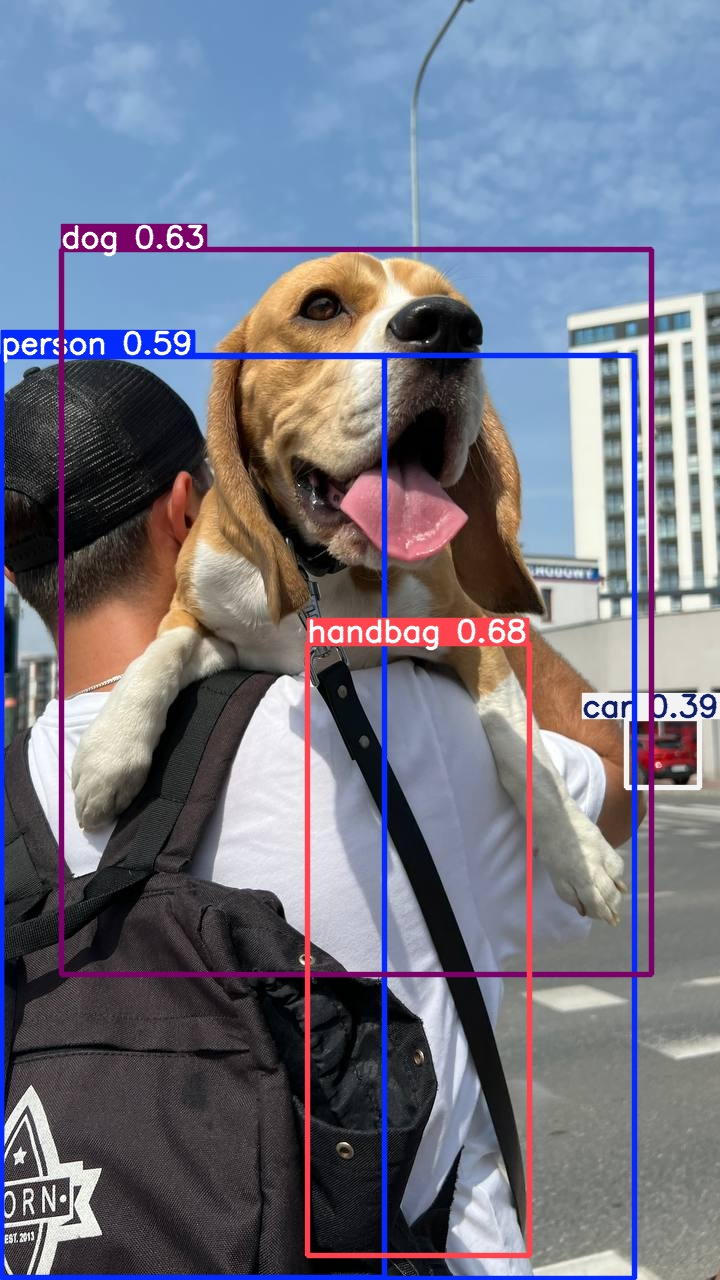

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpeg', width=600)

### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 60.1ms
Speed: 3.9ms preprocess, 60.1ms inference, 924.2ms postprocess per image at shape (1, 3, 640, 384)


**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [ ]:
result.boxes.xyxy

tensor([[3.0705e+02, 6.4341e+02, 5.2919e+02, 1.2558e+03],
        [6.1400e+01, 2.4994e+02, 6.5165e+02, 9.7412e+02],
        [1.7803e+00, 3.5551e+02, 6.3404e+02, 1.2788e+03],
        [1.1933e+00, 3.5620e+02, 3.8455e+02, 1.2776e+03],
        [6.2615e+02, 7.1818e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [ ]:
result.boxes.conf

tensor([0.6832, 0.6284, 0.5941, 0.3923, 0.3875], device='cuda:0')

In [ ]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

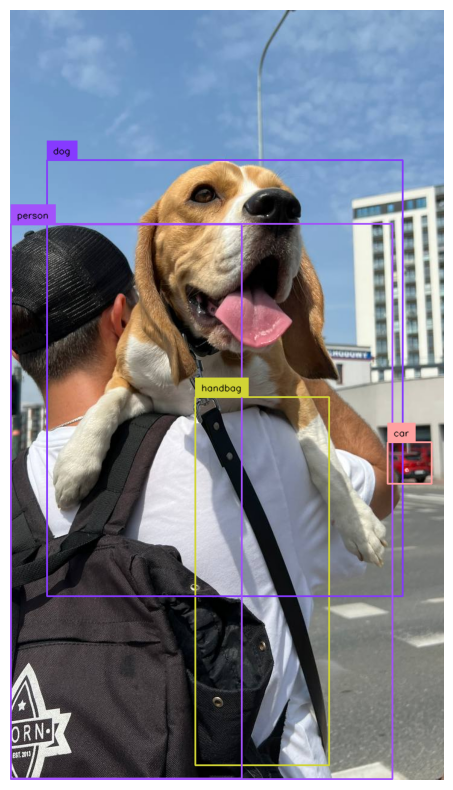

In [ ]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("liangdianzhong")
project = workspace.project("-qvdww")
version = project.version(3)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 两点钟模型-3 in yolov11:: 100%|██████████| 2612/2612 [00:00<00:00, 5820.46it/s]


## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    PR_curve.png	   val_batch0_pred.jpg
confusion_matrix_normalized.png			    R_curve.png		   val_batch1_labels.jpg
confusion_matrix.png				    results.csv		   val_batch1_pred.jpg
events.out.tfevents.1727788453.c5dcf32815d2.3299.0  results.png		   val_batch2_labels.jpg
F1_curve.png					    train_batch0.jpg	   val_batch2_pred.jpg
labels_correlogram.jpg				    train_batch1.jpg	   weights
labels.jpg					    train_batch2.jpg
P_curve.png					    val_batch0_labels.jpg


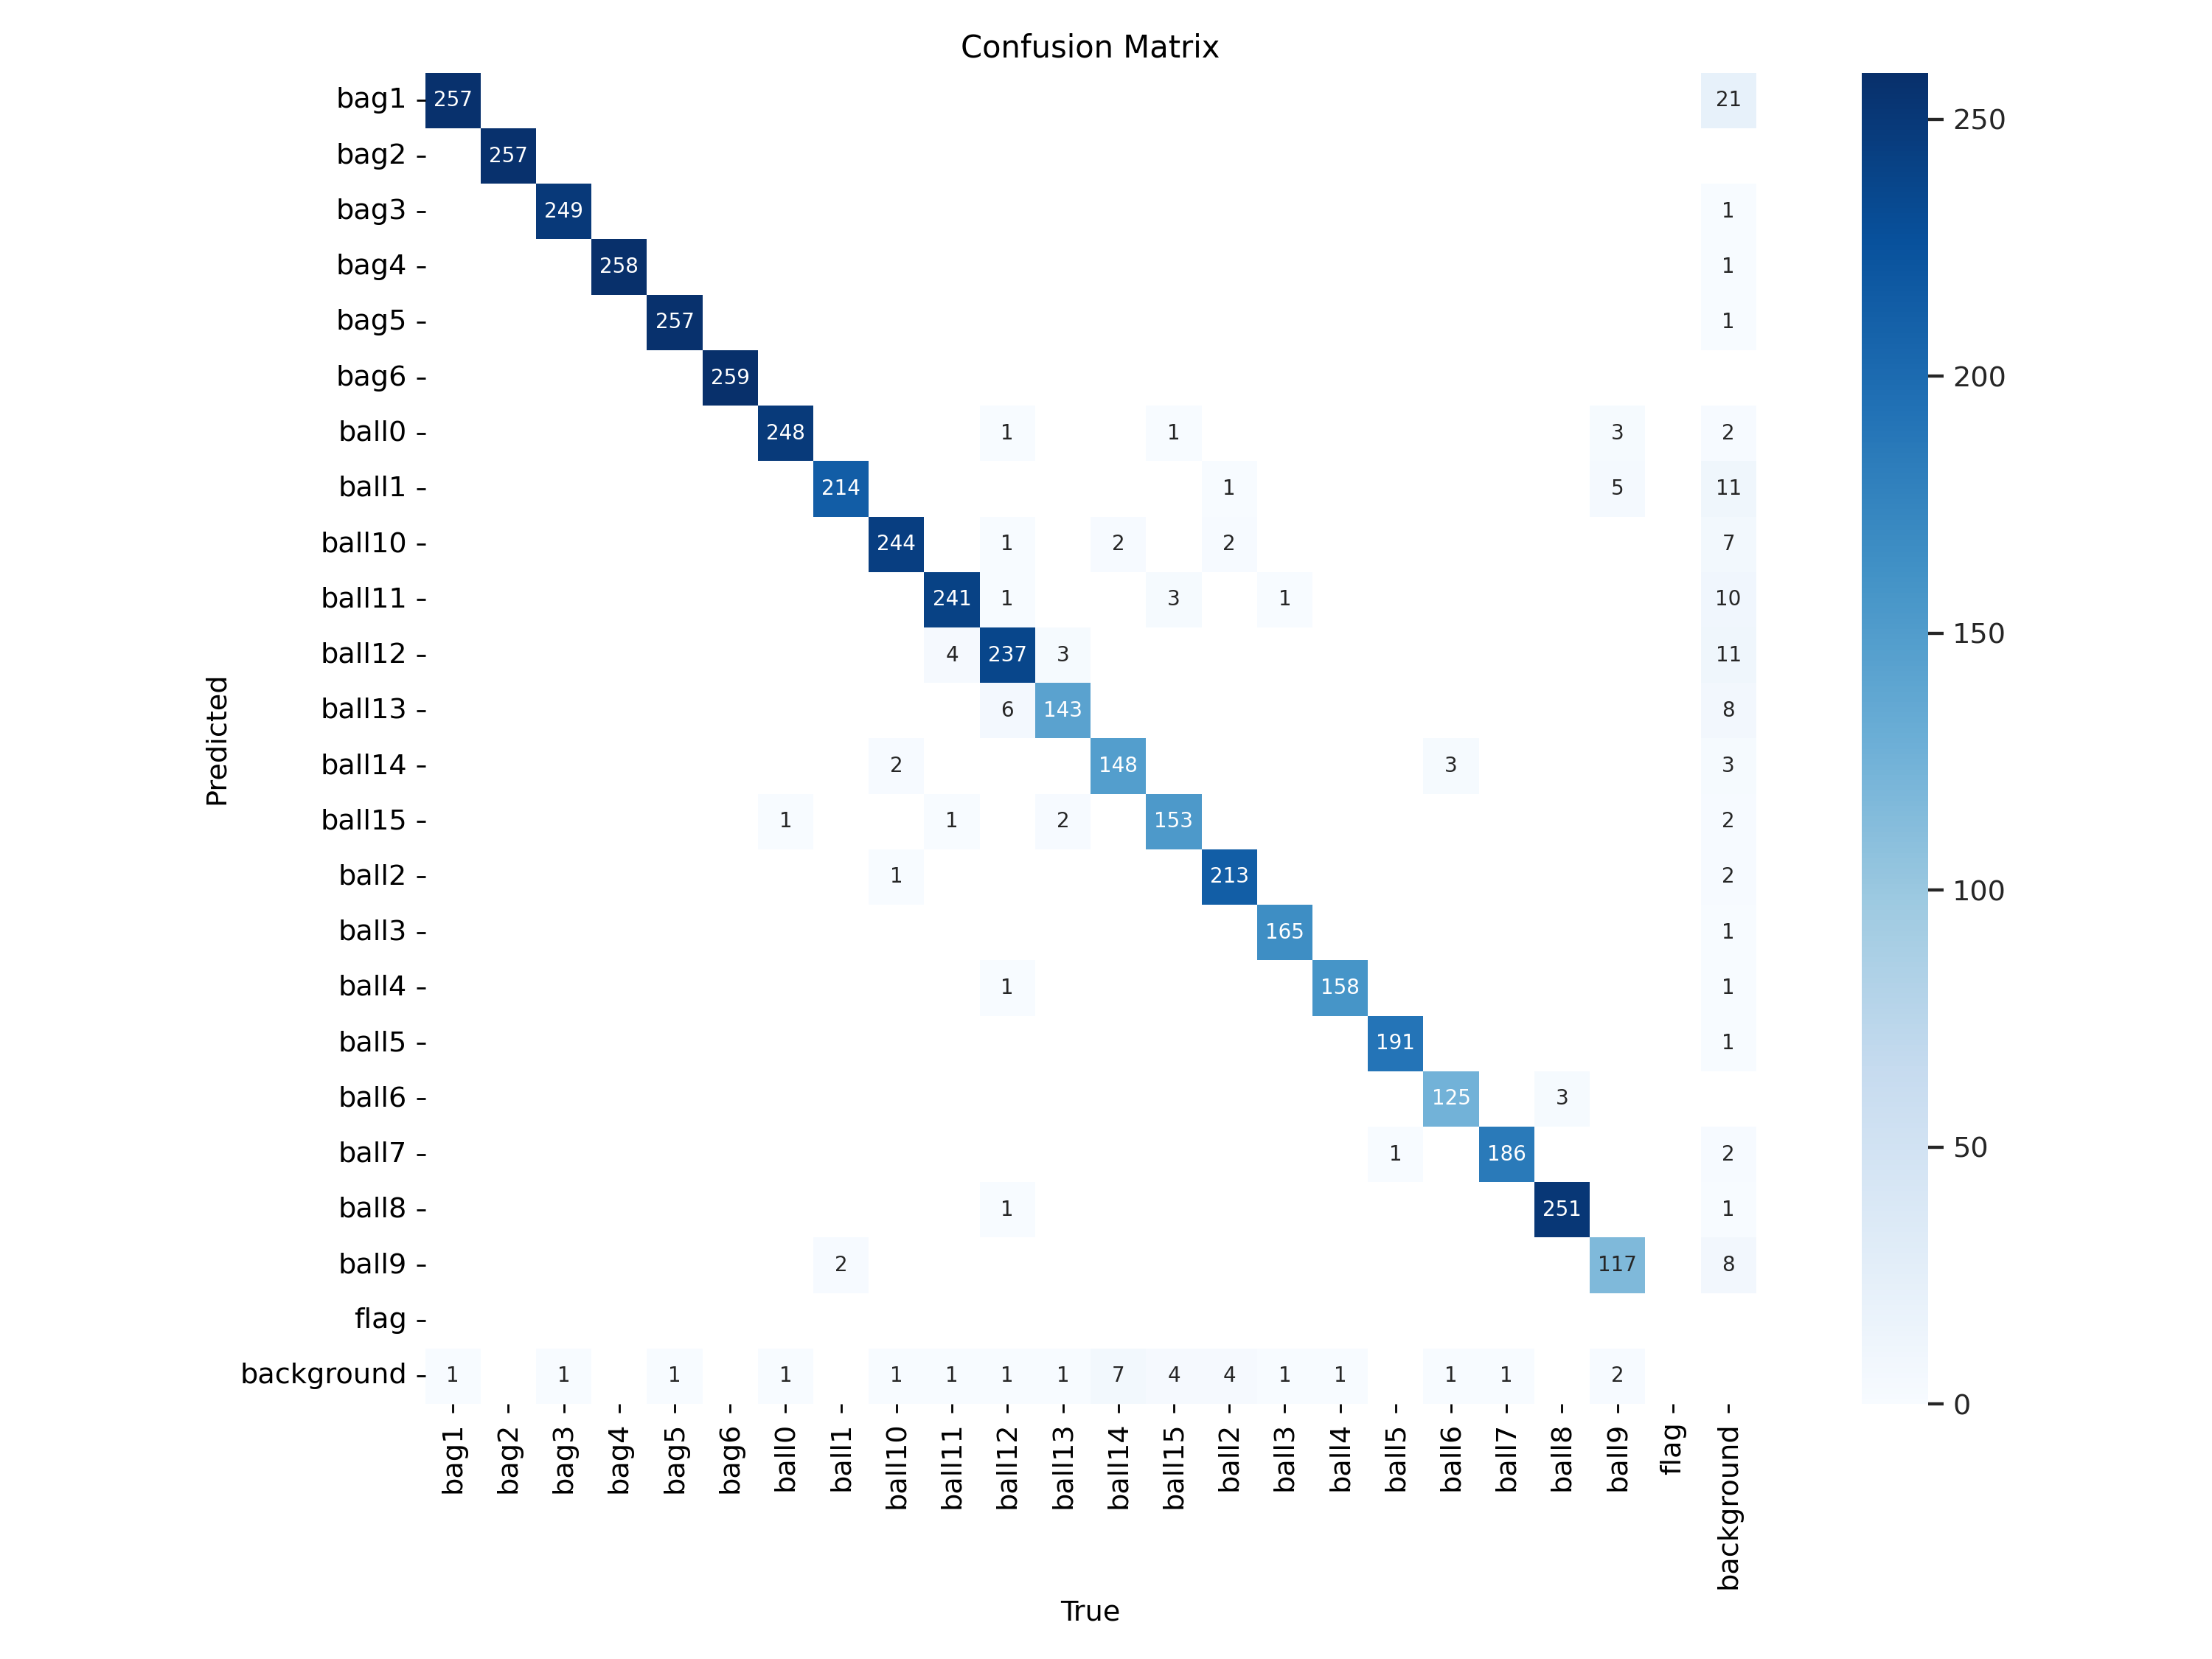

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

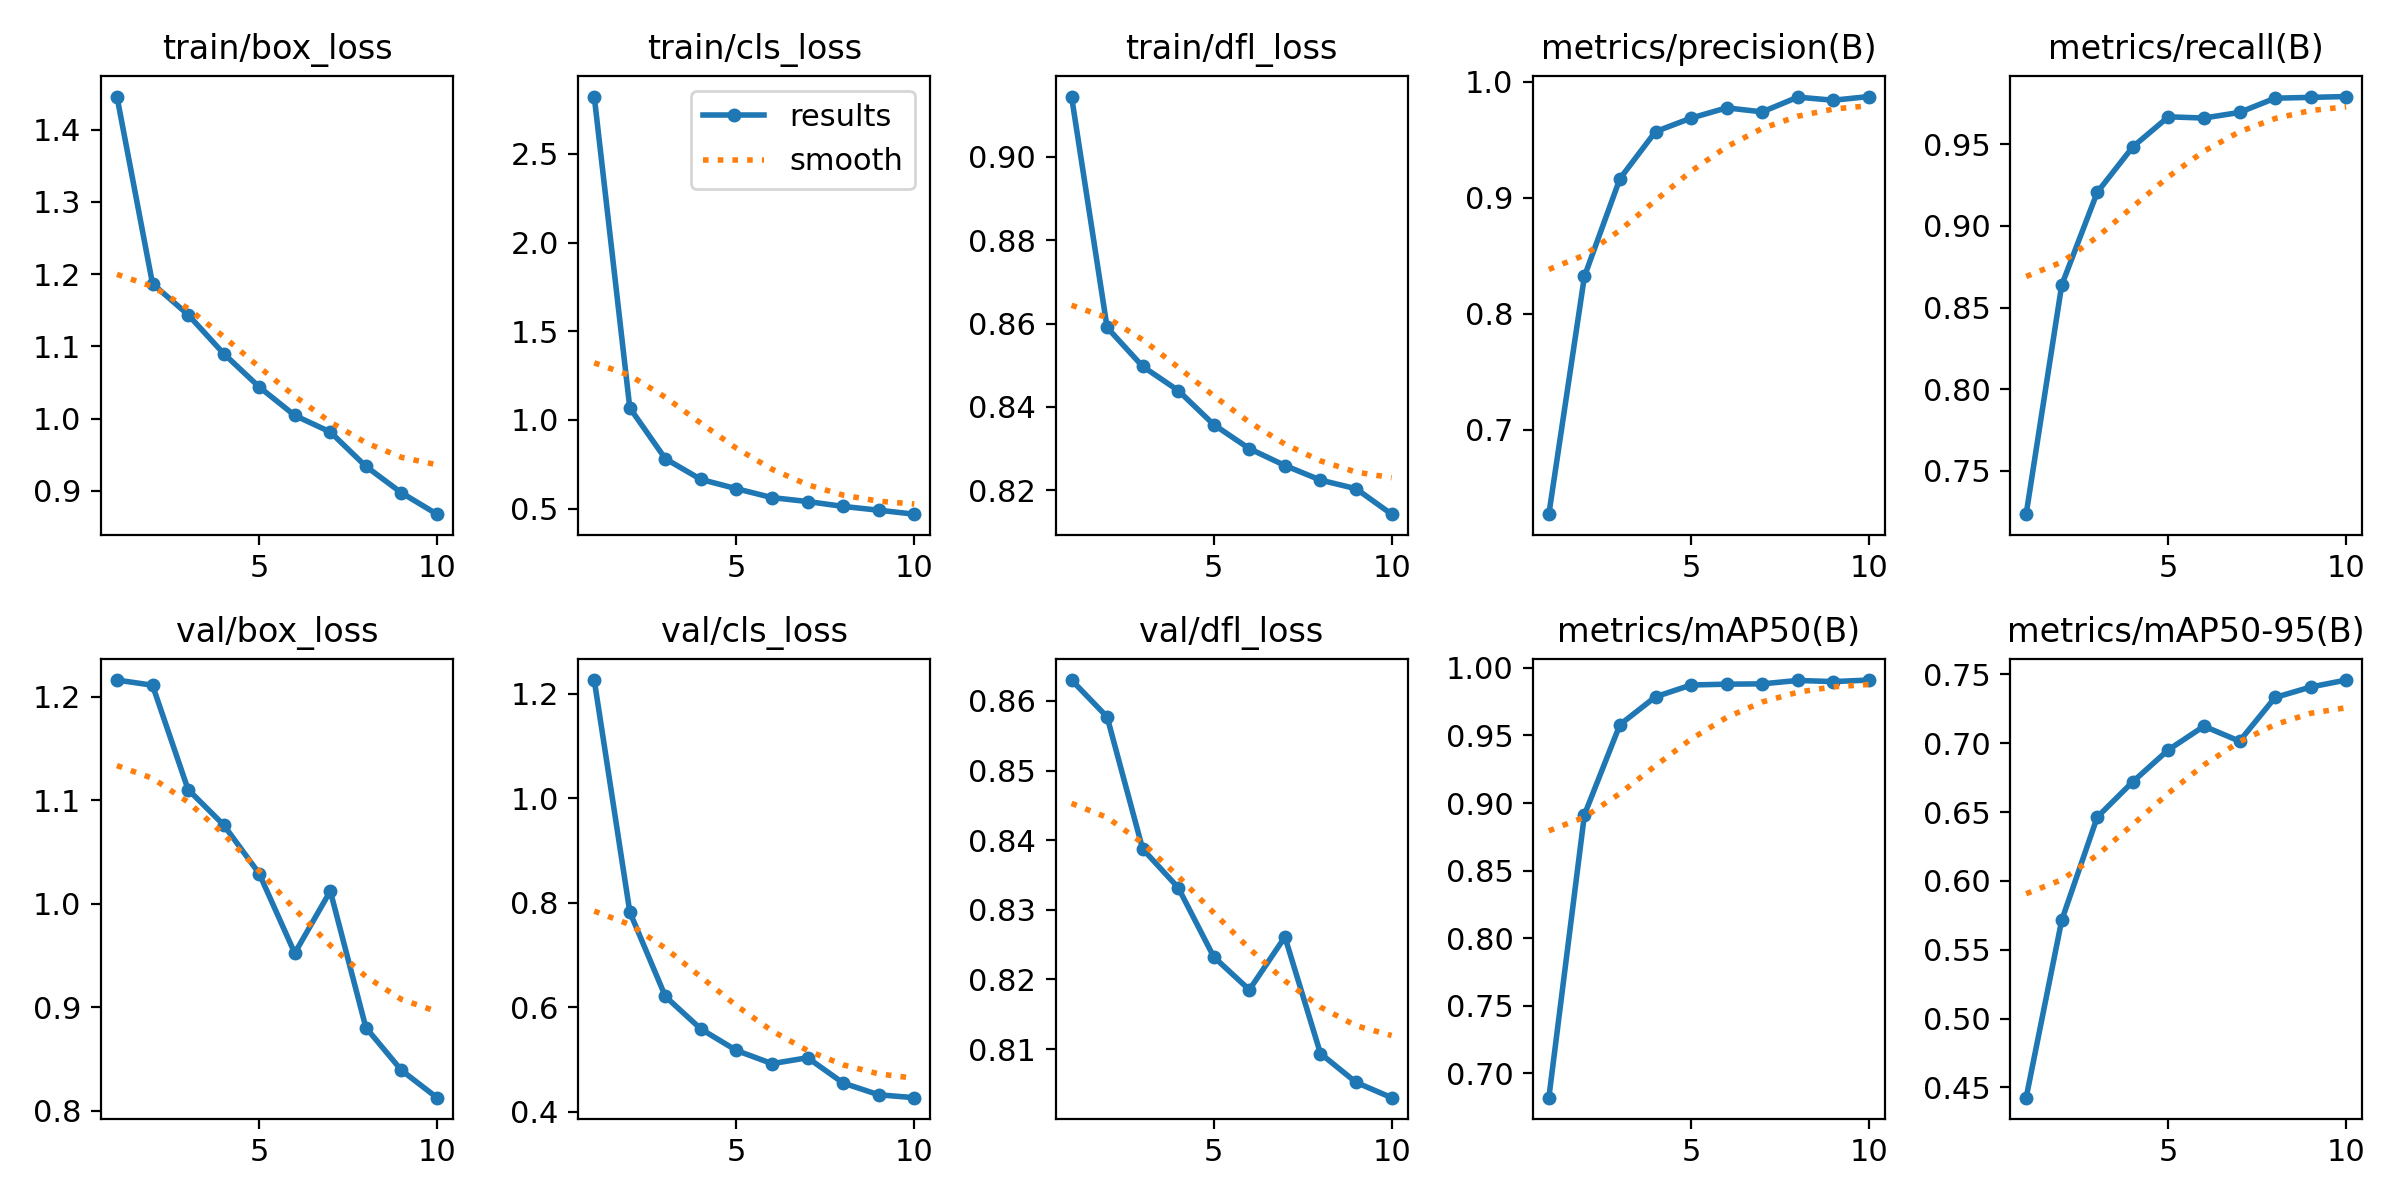

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

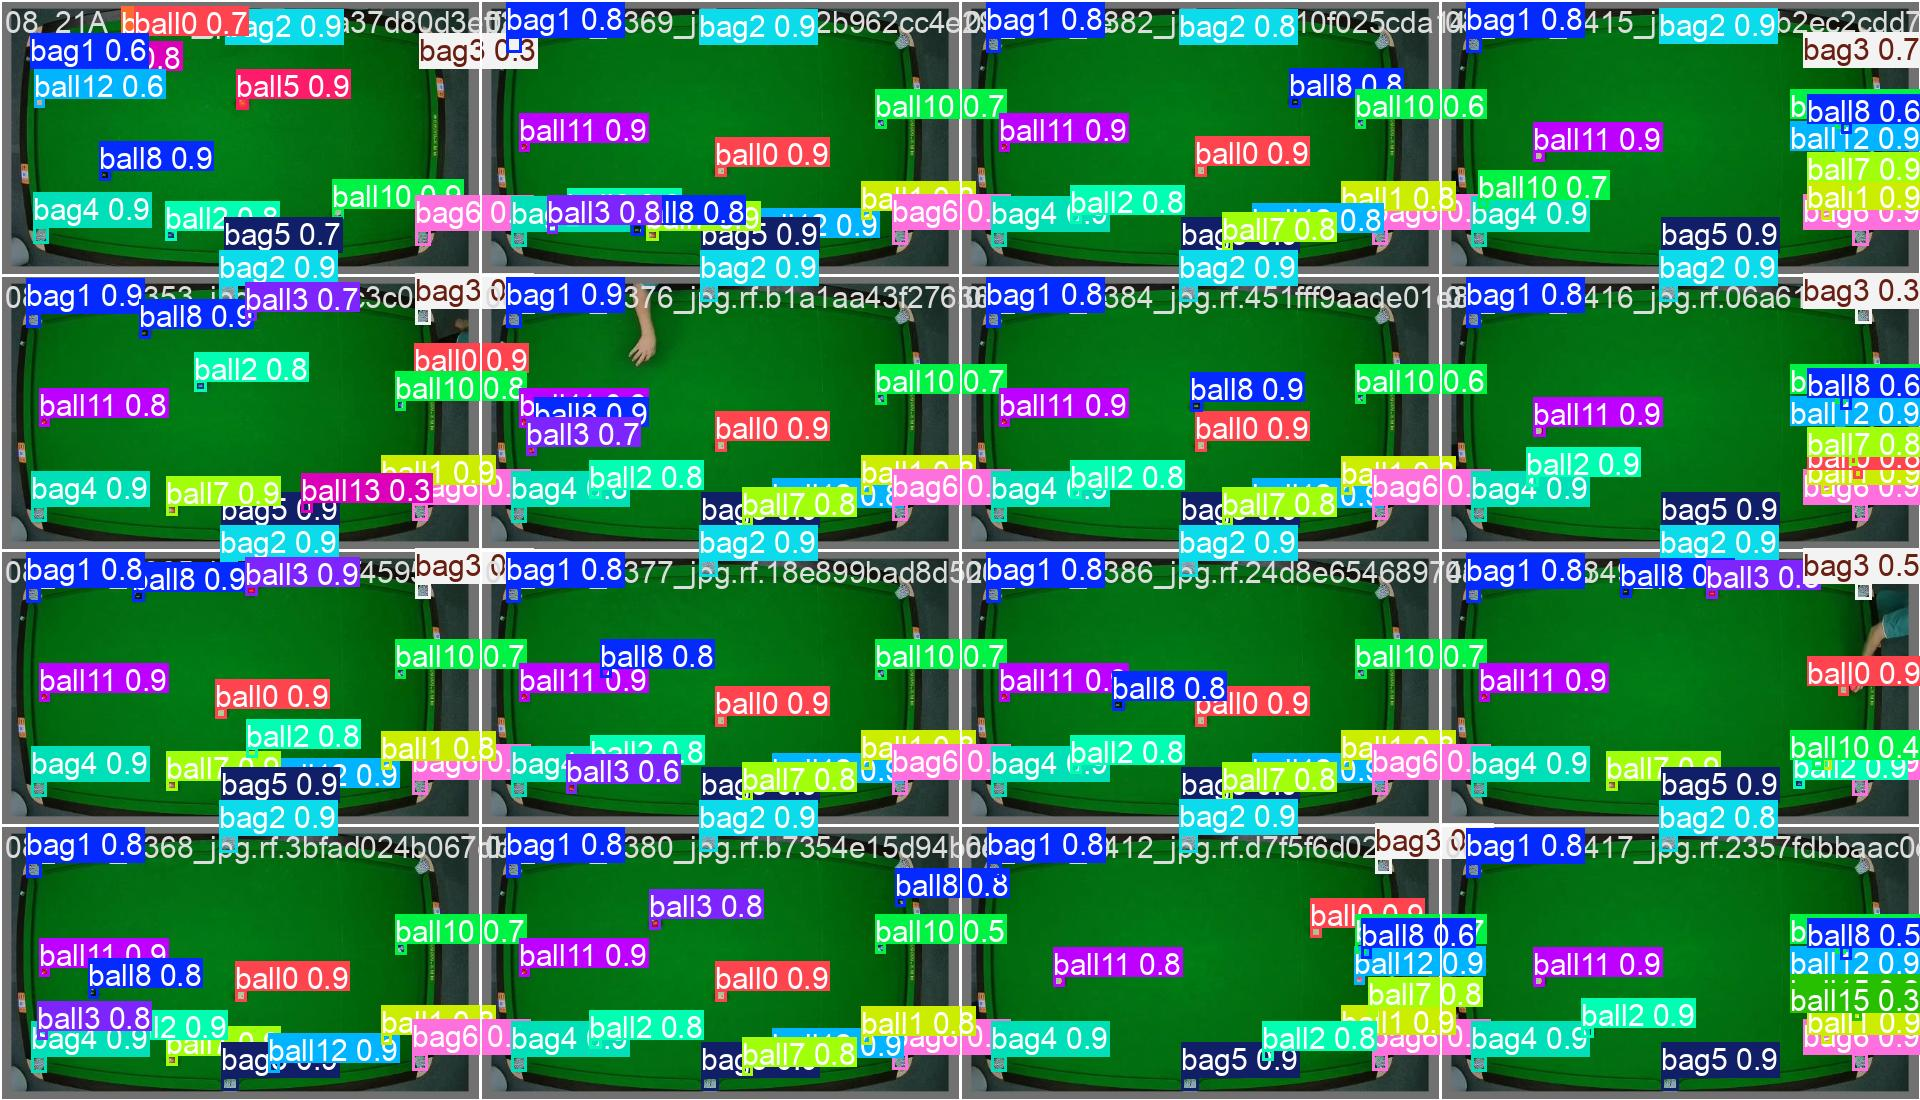

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.2 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11s summary (fused): 238 layers, 9,421,701 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/两点钟模型-3/valid/labels.cache... 259 images, 0 backgrounds, 0 corrupt: 100% 259/259 [00:00<?, ?it/s]
val: WARNING ⚠️ /content/datasets/两点钟模型-3/valid/images/08_21C_0250_jpg.rf.b164fca68a7a644a126019aa776912c1.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 17/17 [00:06<00:00,  2.59it/s]
                   all        259       4652      0.987      0.979      0.991      0.749
                  bag1        258        258      0.986      0.984      0.994       0.78
                  bag2        257        257      0.998          1      0.995      0.892
                  bag3        250        250          1      0.942      0.995      0.808
                  bag4        258        258      0.996          1      0.995      0

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

**NOTE:** Let's take a look at few results.

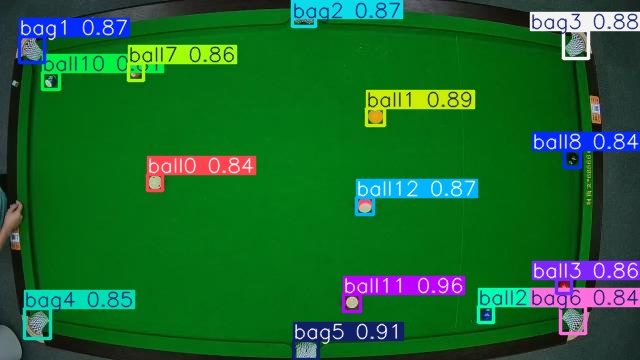

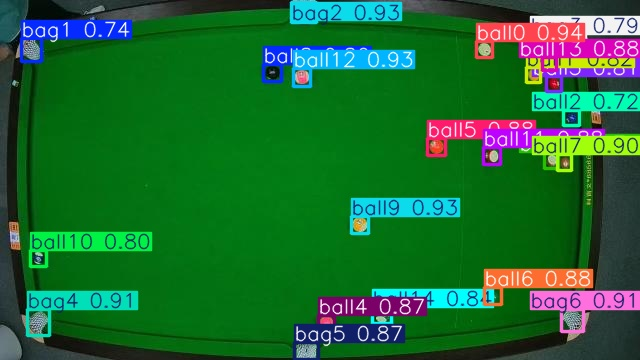

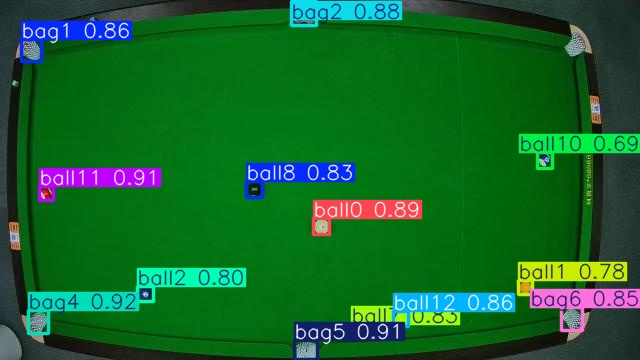

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [ ]:
project.version(dataset.version).deploy(model_type="yolov11", model_path=f"{HOME}/runs/detect/train/")

In [ ]:
!pip install inference

In [ ]:
import os, random, cv2
import supervision as sv
import IPython
import inference

model_id = project.id.split("/")[1] + "/" + dataset.version
model = inference.get_model(model_id, userdata.get('ROBOFLOW_API_KEY'))

# Location of test set images
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image = cv2.imread(os.path.join(test_set_loc, img_name))

    # Perform inference
    results = model.infer(image, confidence=0.4, overlap=30)[0]
    detections = sv.Detections.from_inference(results)

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)


## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.

# Paso1 : Instalar Roboflow y ultralytics

In [ ]:
!pip install roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


# Paso2: Descargar el dataset personalizado desde Roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="aoqQpN54YWQBS0Wxmc9U")
project = rf.workspace("seabirdsccs").project("ai-seabirds")
version = project.version(7)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to AI-Seabirds-7 in yolo26:: 100%|██████████| 2804/2804 [00:00<00:00, 6300.40it/s]


# Paso 3: Cargar el modelo base Yolo v12

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26x.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# paso 4 : Entrenar el modelo personalizado

In [ ]:
data_path = "/content/AI-Seabirds-7/data.yaml"

model.train(
    data=data_path,
    epochs=100,
    patience=10,
    batch=-1,
    imgsz=640
) #12nanov1.pt

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AI-Seabirds-7/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 7,  8, 11, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e7f53bc4170>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


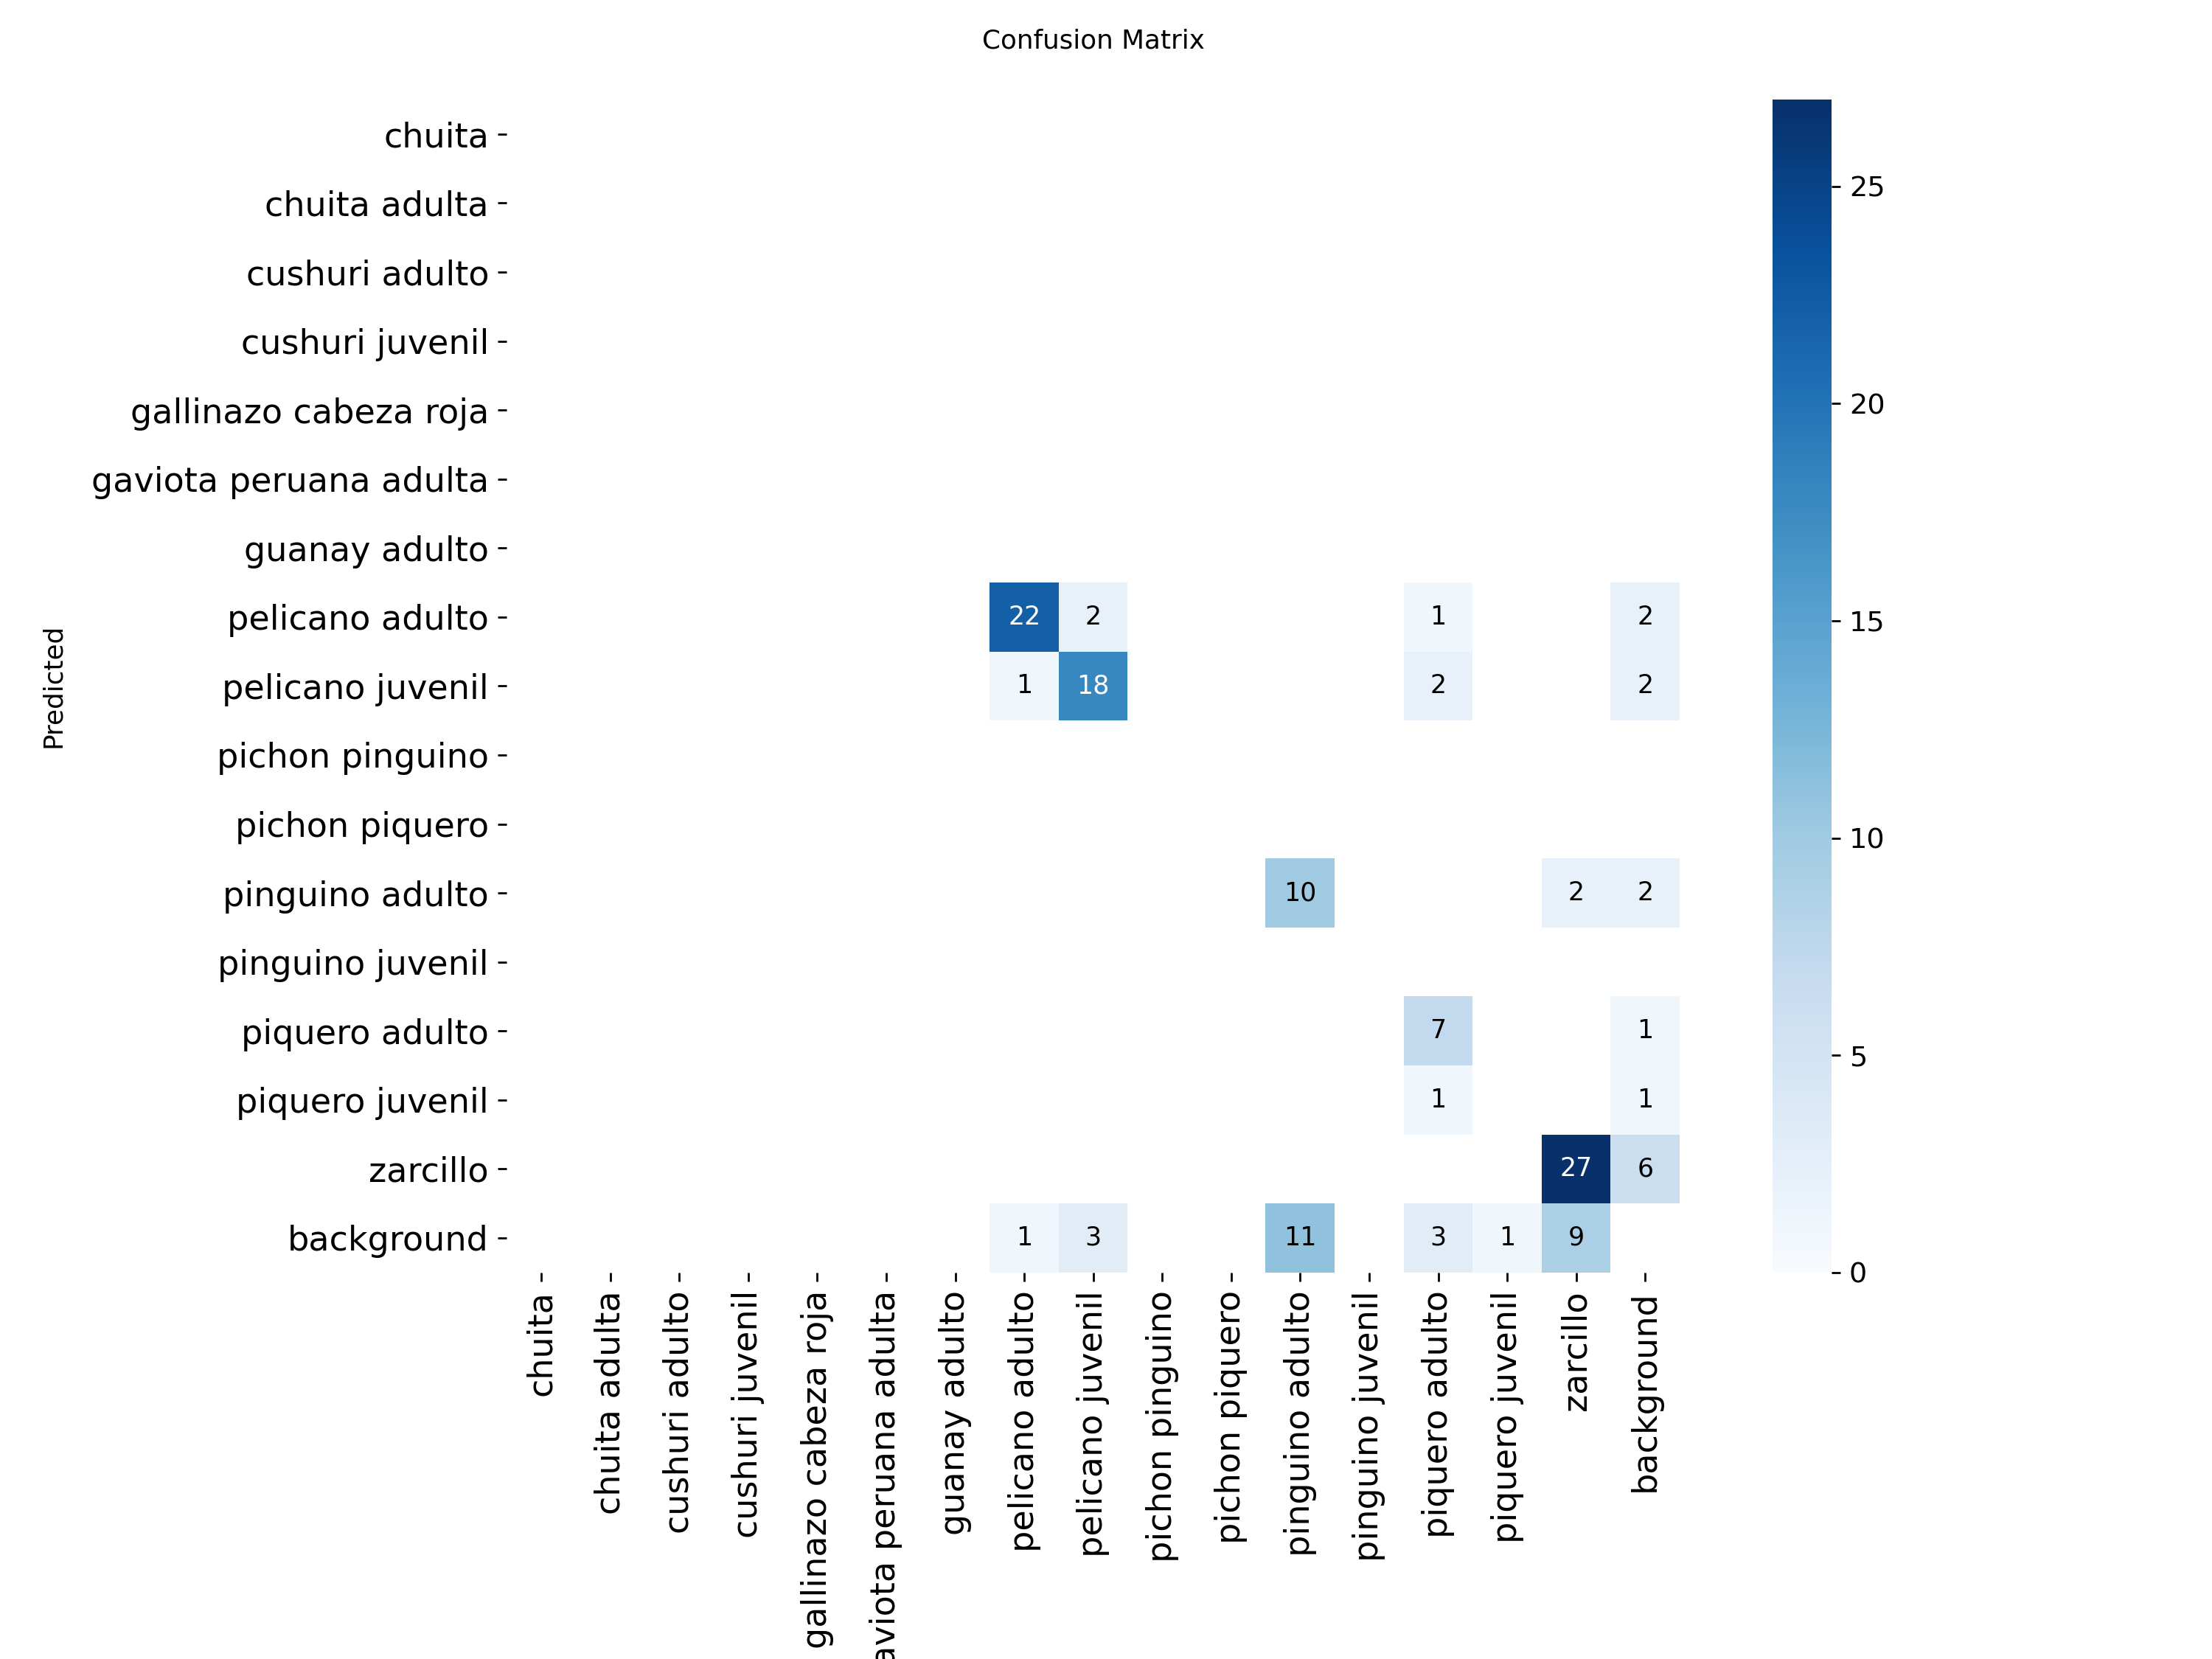

In [ ]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

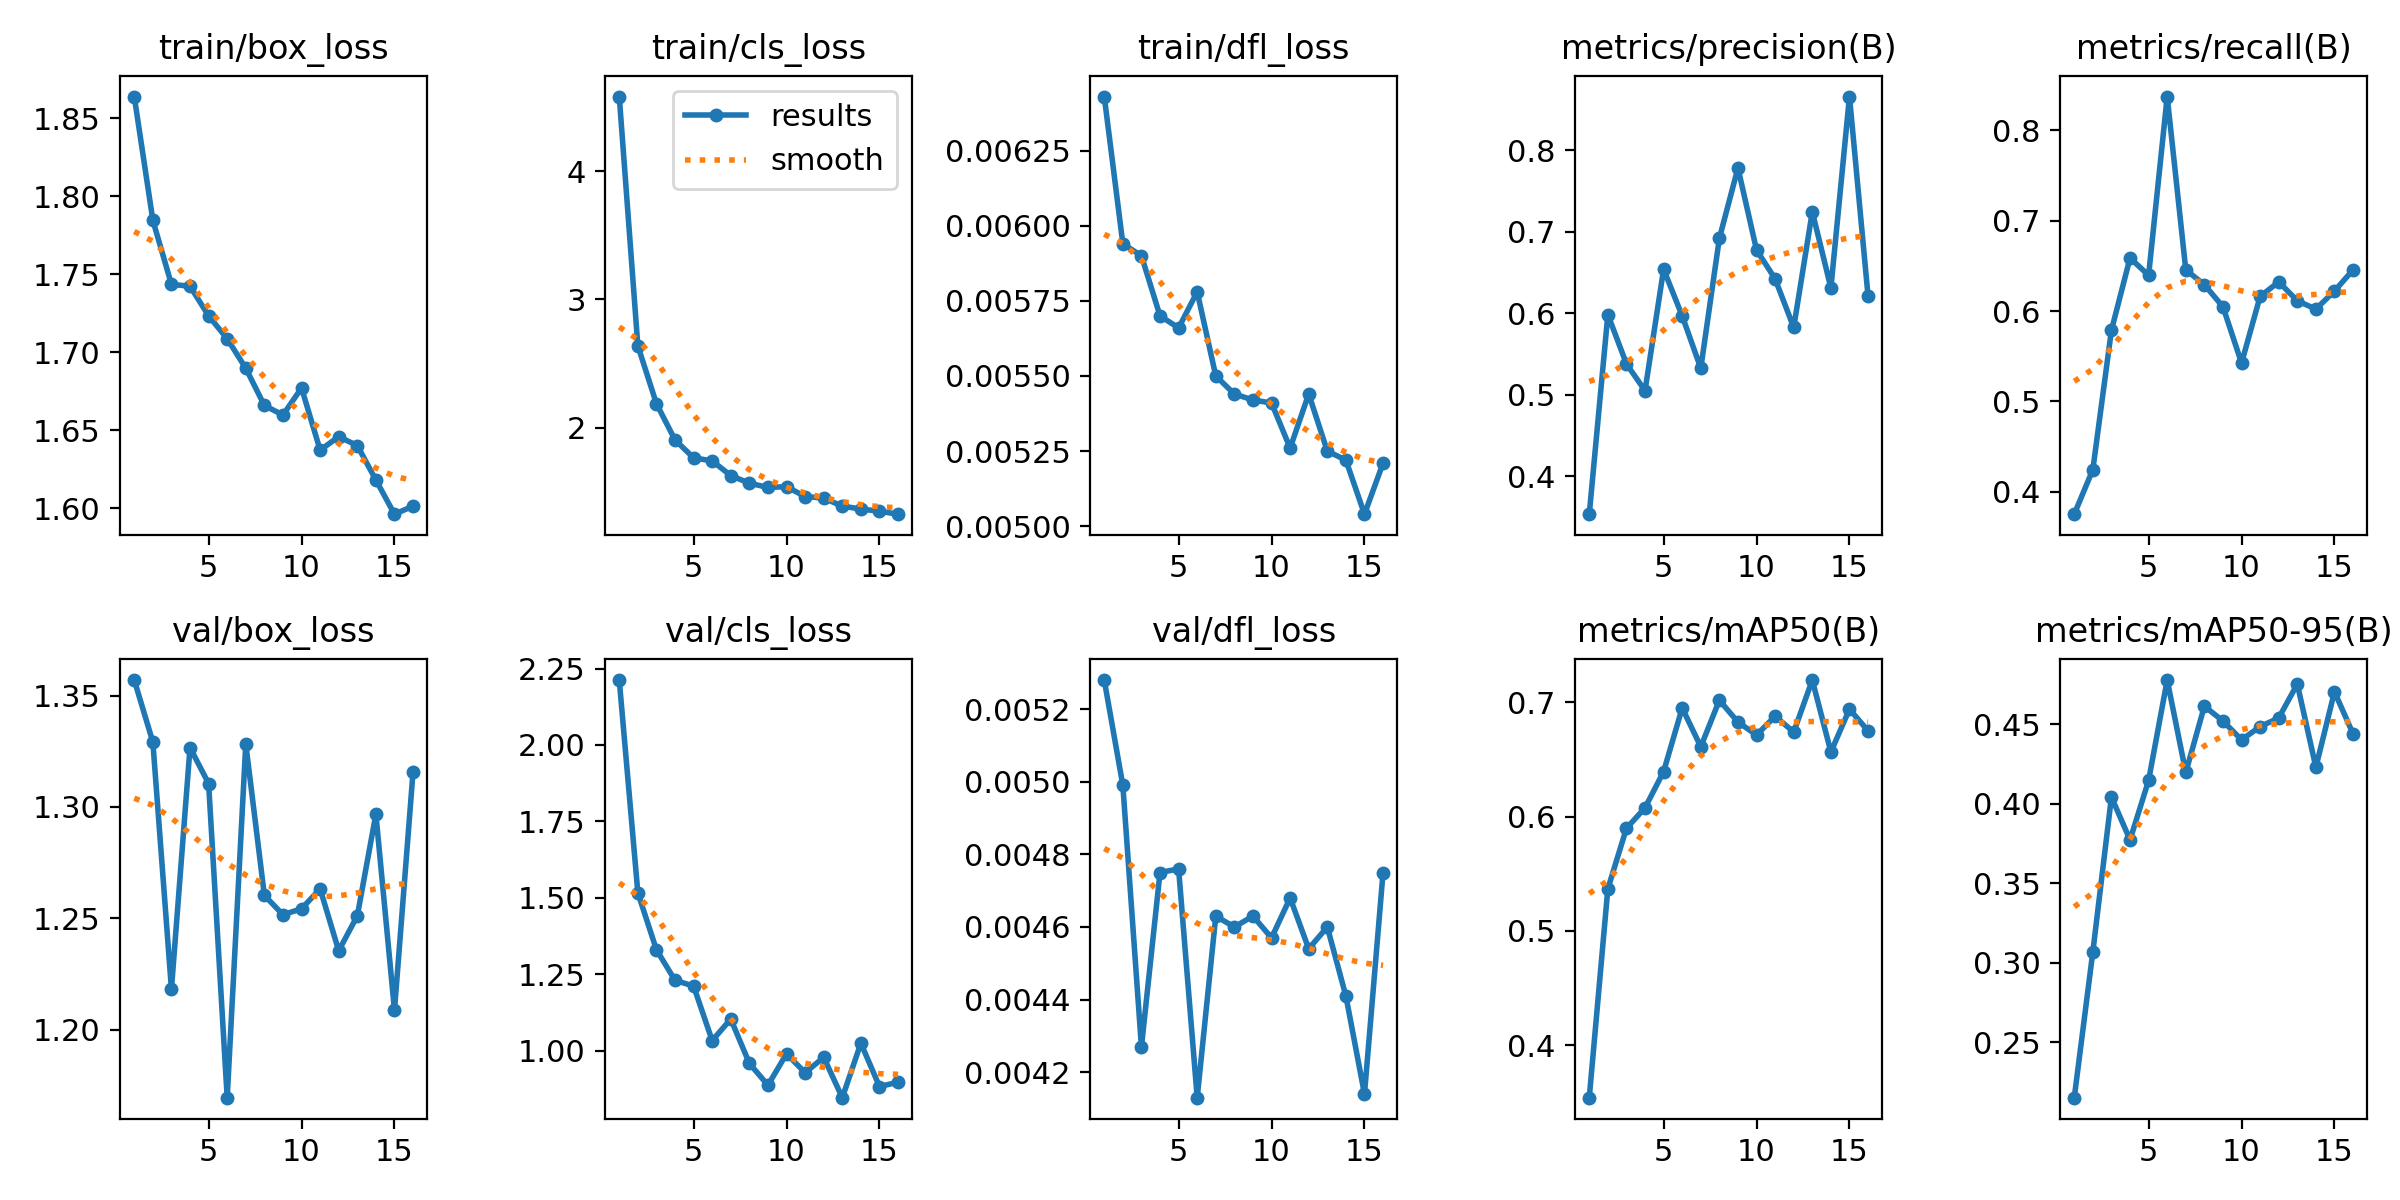

In [ ]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/results.png', width=1000)

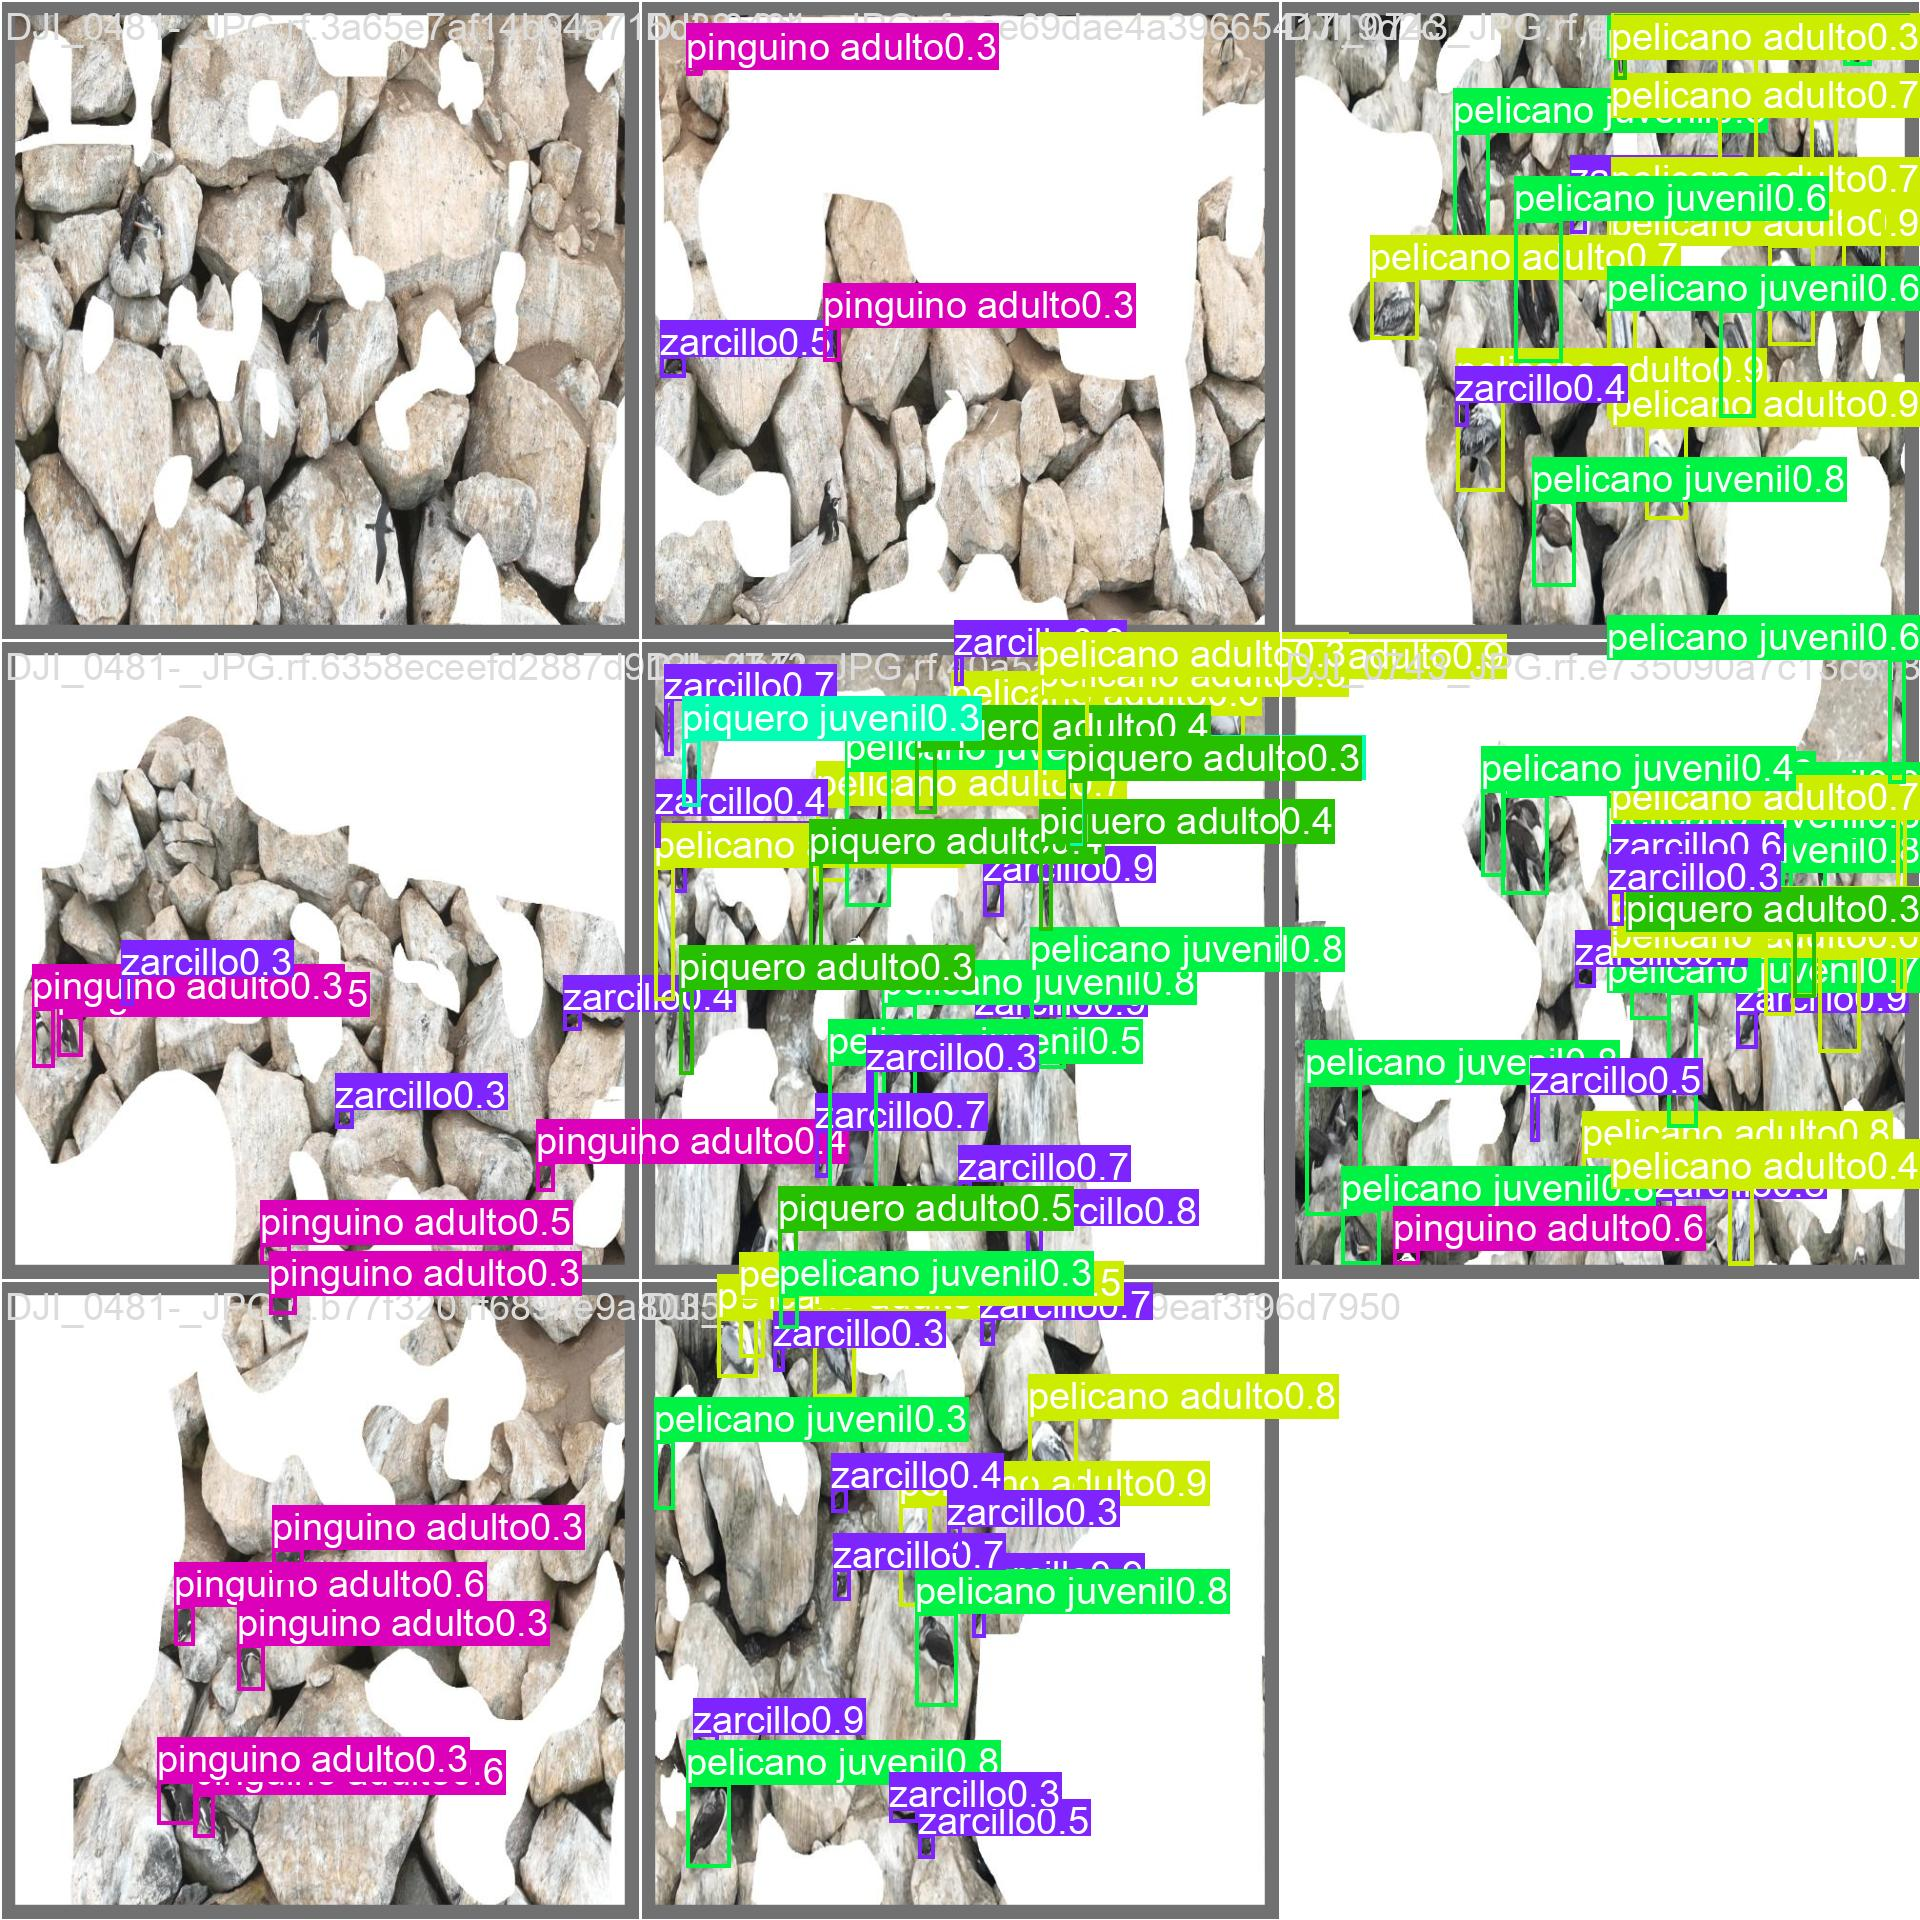

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

=== Diagnóstico de sobre-ajuste ===
Gap box-loss (últimas 10 épocas): 0.902


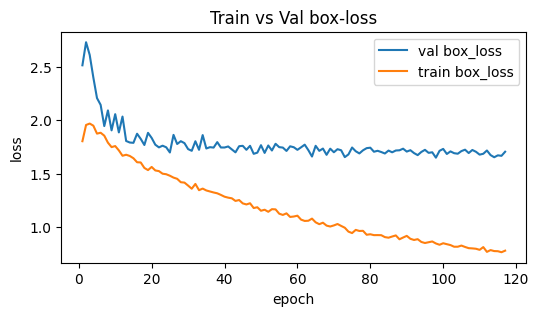

⚠️ Posible sobre-ajuste


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Cargar CSV
csv = "/content/runs/detect/train2/results.csv"
df = pd.read_csv(csv)

# 2) Brecha simple: val vs train LOSS
gap_box = abs(df['val/box_loss'] - df['train/box_loss'])
mean_gap = gap_box.tail(10).mean()

print("=== Diagnóstico de sobre-ajuste ===")
print(f"Gap box-loss (últimas 10 épocas): {mean_gap:.3f}")

# 3) Gráfico rápido
plt.figure(figsize=(6, 3))
plt.plot(df['epoch'], df['val/box_loss'], label='val box_loss')
plt.plot(df['epoch'], df['train/box_loss'], label='train box_loss')
plt.legend()
plt.title('Train vs Val box-loss')
plt.xlabel('epoch'); plt.ylabel('loss')
plt.show()

# 4) Regla rápida
if mean_gap > 0.3:
    print("⚠️ Posible sobre-ajuste")
else:
    print("✅ Sin señales claras de sobre-ajuste")

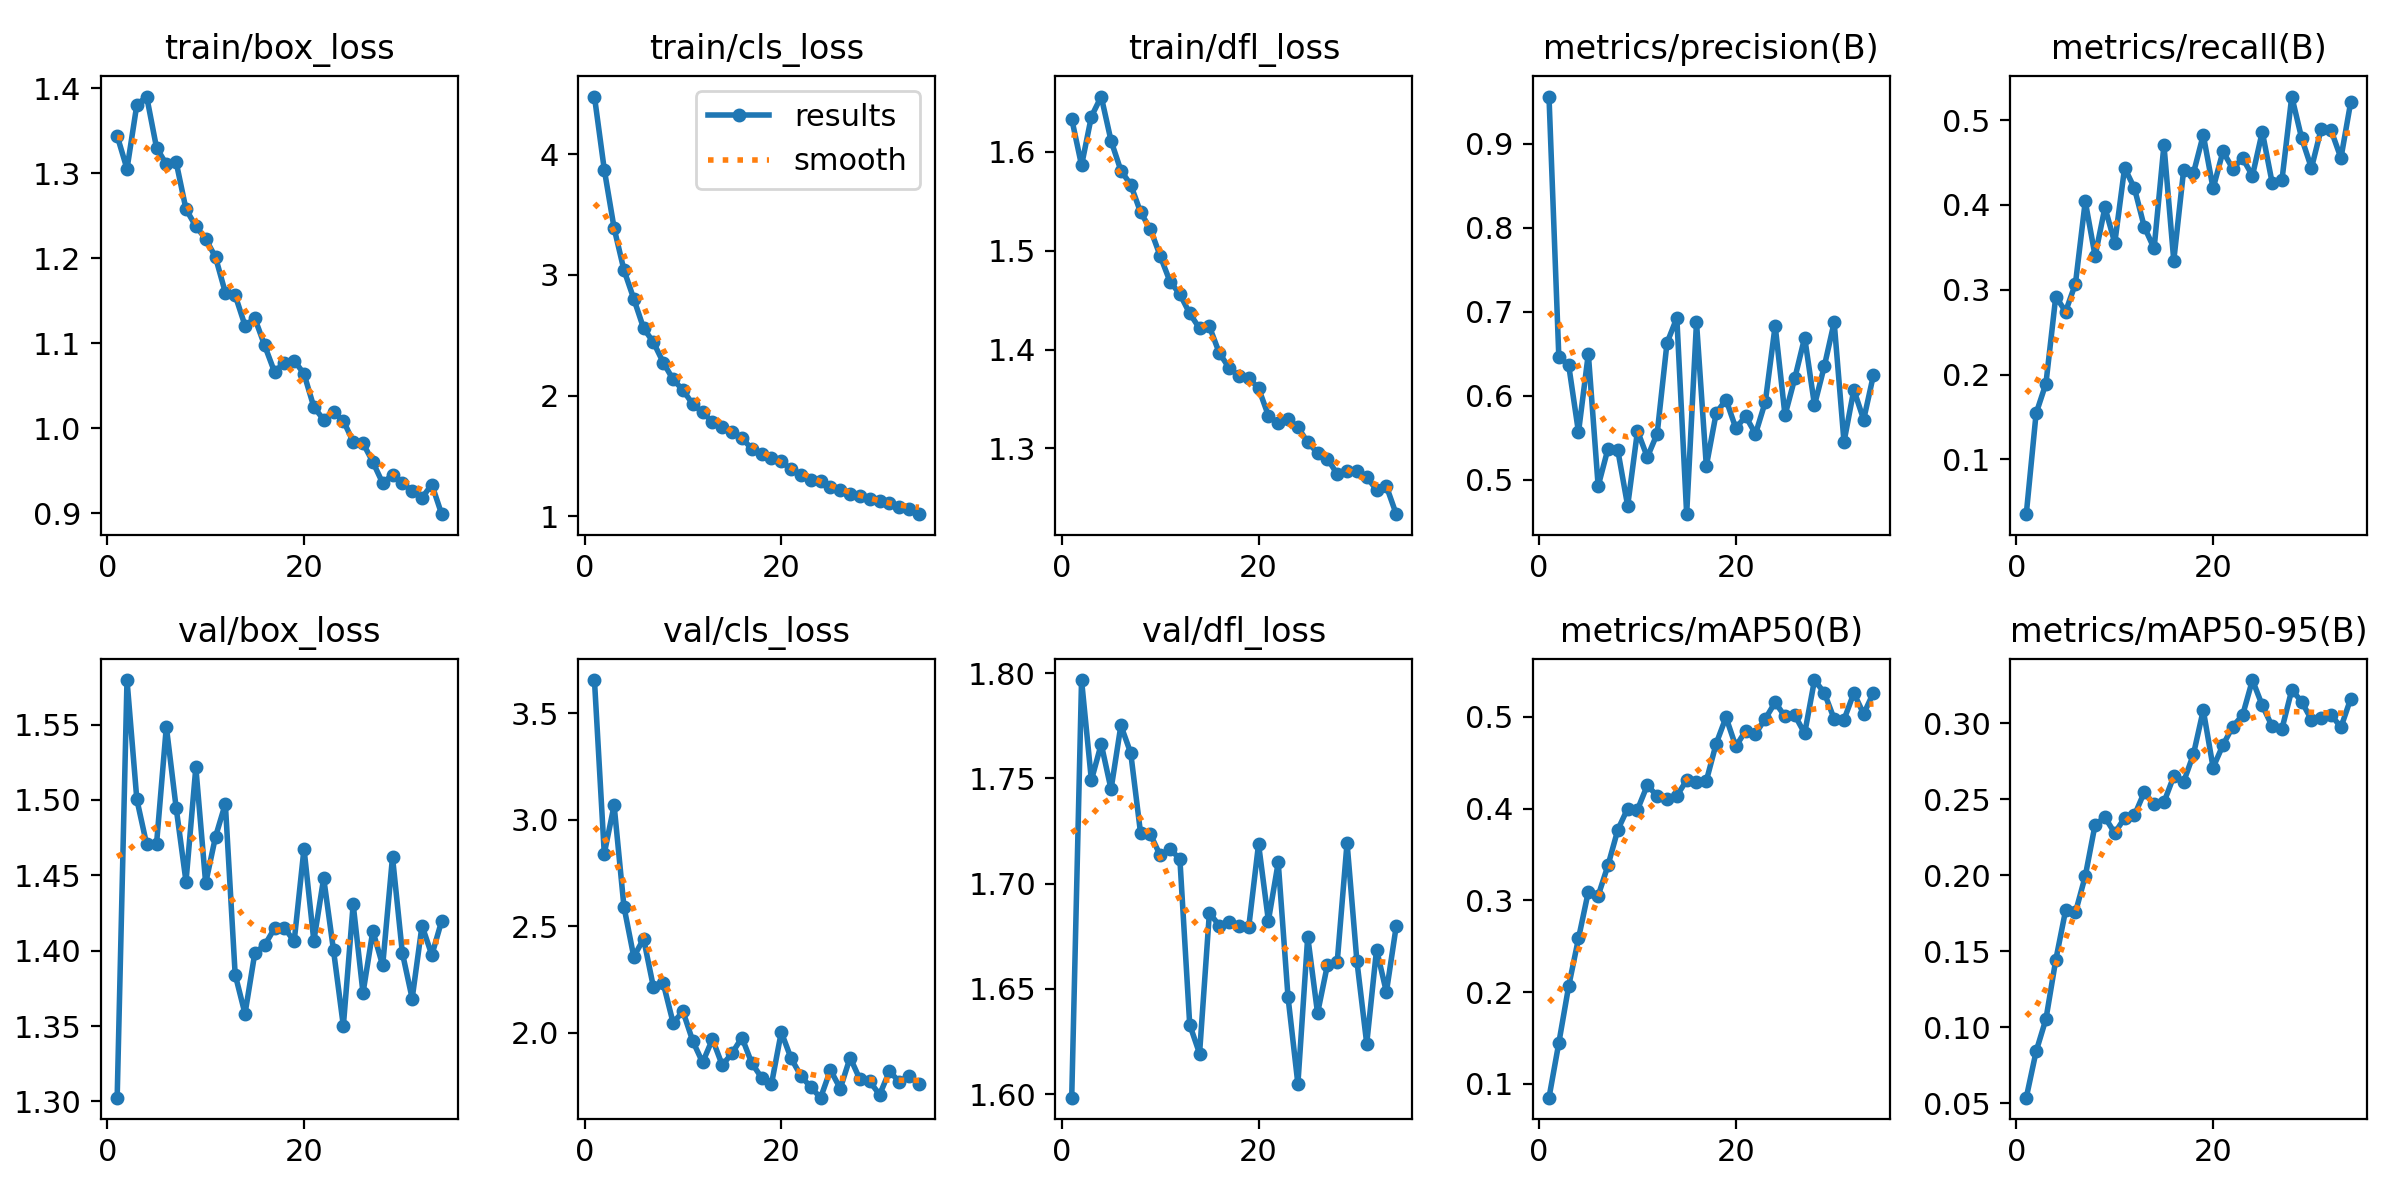

In [ ]:
from IPython.display import Image as IPyImage
IPyImage(filename="/content/runs/detect/train/results.png",width=800)

# Hacemos las predicciones

In [ ]:
custom_model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
res = custom_model("/content/AI-Seabirds-5/test/images")


image 1/20 /content/AI-Seabirds-5/test/images/DJI_0065_JPG.rf.1f1a2e7ff1e3bf38b5431bc9946fcb59.jpg: 640x640 5 piquero adultos, 7 piquero juvenils, 4 zarcillos, 15.1ms
image 2/20 /content/AI-Seabirds-5/test/images/DJI_0065_JPG.rf.46c86455717733841f11ebe29ac9f29e.jpg: 640x640 2 piquero juvenils, 6 zarcillos, 10.7ms
image 3/20 /content/AI-Seabirds-5/test/images/DJI_0065_JPG.rf.994cfb4d1c7a2157ba22b66e04ba4216.jpg: 640x640 1 pelicano juvenil, 4 piquero adultos, 5 piquero juvenils, 4 zarcillos, 11.0ms
image 4/20 /content/AI-Seabirds-5/test/images/DJI_0065_JPG.rf.dc69f7e380268551573de4779b908447.jpg: 640x640 2 piquero adultos, 10.5ms
image 5/20 /content/AI-Seabirds-5/test/images/DJI_0381_JPG.rf.4ebb88f5bb92996bfde346ace2b9ec4f.jpg: 640x640 (no detections), 10.2ms
image 6/20 /content/AI-Seabirds-5/test/images/DJI_0381_JPG.rf.6aa84d7057ecbada6de72b6764323962.jpg: 640x640 6 piquero adultos, 12 piquero juvenils, 15.4ms
image 7/20 /content/AI-Seabirds-5/test/images/DJI_0381_JPG.rf.95e28bcec282ec

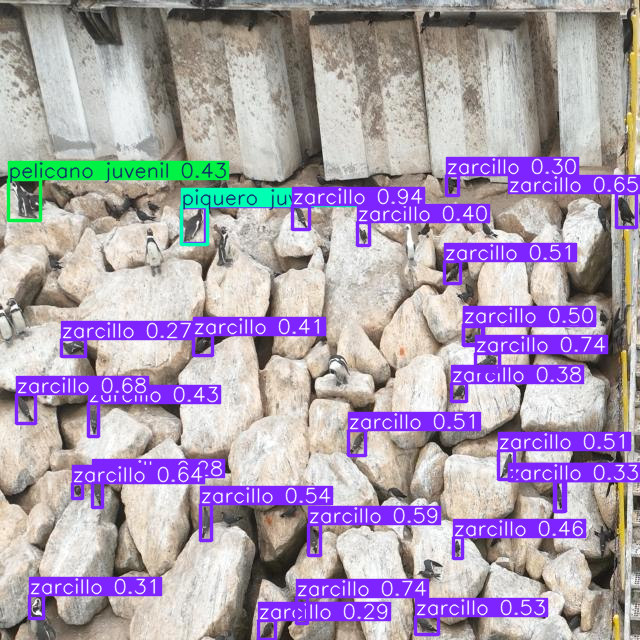

In [ ]:
res[12].show()

In [ ]:
import pandas as pd
import os

all_preds = []

for r in res:
    image_path = r.path  # Ruta completa de la imagen
    image_name = os.path.basename(image_path)  # Solo el nombre del archivo

    boxes = r.boxes
    for box in boxes:
        b = box.xyxy[0].tolist()
        conf = box.conf[0].item()
        cls = int(box.cls[0].item())
        name = r.names[cls]

        all_preds.append({
            "image": image_name,     #  aquí agregamos el nombre de imagen
            "x1": b[0],
            "y1": b[1],
            "x2": b[2],
            "y2": b[3],
            "confidence": conf,
            "class_id": cls,
            "class_name": name
        })

# Convertir a DataFrame
df_preds = pd.DataFrame(all_preds)




In [ ]:
df_preds

""


In [ ]:
from ultralytics.utils import DEFAULT_CFG

print(DEFAULT_CFG)


task=detect
mode=train
model=None
data=None
epochs=100
time=None
patience=100
batch=16
imgsz=640
save=True
save_period=-1
cache=False
device=None
workers=8
project=None
name=None
exist_ok=False
pretrained=True
optimizer=auto
verbose=True
seed=0
deterministic=True
single_cls=False
rect=False
cos_lr=False
close_mosaic=10
resume=False
amp=True
fraction=1.0
profile=False
freeze=None
multi_scale=False
overlap_mask=True
mask_ratio=4
dropout=0.0
val=True
split=val
save_json=False
conf=None
iou=0.7
max_det=300
half=False
dnn=False
plots=True
source=None
vid_stride=1
stream_buffer=False
visualize=False
augment=False
agnostic_nms=False
classes=None
retina_masks=False
embed=None
show=False
save_frames=False
save_txt=False
save_conf=False
save_crop=False
show_labels=True
show_conf=True
show_boxes=True
line_width=None
format=torchscript
keras=False
optimize=False
int8=False
dynamic=False
simplify=True
opset=None
workspace=None
nms=False
lr0=0.01
lrf=0.01
momentum=0.937
weight_decay=0.0005
warmup_ep

In [ ]:
import os, pandas as pd
from collections import Counter
from ultralytics import YOLO

model_path = "/content/runs/detect/train/weights/best.pt"
model = YOLO(model_path)

img_dir   = "/content/Multiclase-Objetos-Object-Detection-13/valid/images"
label_dir = img_dir.replace("images", "labels")

idx2cls = {
    0: "Ave marina", 1: "Ave terrestre", 2: "Cactus", 3: "Cielo", 4: "DDV",
    5: "Desierto", 6: "Flor", 7: "Lagartija", 8: "Lago", 9: "Macroinvertebrados",
    10: "Mar", 11: "Murcielago", 12: "Pastizal", 13: "Pelicano", 14: "Pez",
    15: "Pinguino", 16: "Plancton", 17: "Planta", 18: "Playa", 19: "Rana",
    20: "Raton", 21: "Raya", 22: "Ribera", 23: "Rio", 24: "Rompeolas",
    25: "Terminal marino", 26: "Varamiento", 27: "Zarcillo", 28: "arbol",
    29: "cultivo", 30: "humano", 31: "montana"
}

rows = []
for img_name in os.listdir(img_dir):
    img_path   = os.path.join(img_dir, img_name)
    label_file = img_name.replace(".jpg", ".txt")         # mismo hash
    label_path = os.path.join(label_dir, label_file)

    preds = model.predict(img_path, conf=0.3, verbose=False)[0]
    detected = Counter(int(c) for c in preds.boxes.cls.cpu().numpy())

    annotated = Counter()
    if os.path.exists(label_path):
        annotated = Counter(int(line.split()[0]) for line in open(label_path))

    for cls_idx in detected:
        missing = detected[cls_idx] - annotated.get(cls_idx, 0)
        if missing > 0:
            rows.append({
                "image": img_name,
                "class_detected": idx2cls[cls_idx],
                "detected_boxes": detected[cls_idx],
                "annotated_boxes": annotated.get(cls_idx, 0),
                "missing_boxes": missing
            })

df = pd.DataFrame(rows)
df.to_excel("revisar_valid.xlsx", index=False)
print("✅ Excel listo: missing_instances_hash.xlsx")

✅ Excel listo: missing_instances_hash.xlsx


In [ ]:
# ==========================
# 0. Preparación común
# ==========================
!pip install -q roboflow ultralytics fiftyone  # fiftyone para análisis de FP/FN

from roboflow import Roboflow
from ultralytics import YOLO
import fiftyone as fo
import fiftyone.zoo as foz
import os, json, shutil
from pathlib import Path

# Descarga el dataset (una sola vez)
rf = Roboflow(api_key="bfqcjGZgnmJeeiGYywOl")
project = rf.workspace("imagenesmultietiqueta").project("multiclase-objetos-object-detection")
dataset = project.version(13).download("yolov8")   # yolov8 formato sirve para ambos modelos
data_yaml = Path(dataset.location) / "data.yaml"

# Carpeta donde guardaremos todo
OUT_DIR = Path("/content/comparacion_yolo")
OUT_DIR.mkdir(exist_ok=True)

# ==========================
# 1. Entrenamiento
# ==========================
models_to_test = {
    "yolov11n": "yolo11n.pt",
    "yolov12n": "yolo12n.pt"
}

for name, ckpt in models_to_test.items():
    print(f"\n>>> Entrenando {name} ...")
    model = YOLO(ckpt)
    model.train(
        data=str(data_yaml),
        epochs=100,
        imgsz=640,
        patience=15,           # <- anti-overfitting
        project=str(OUT_DIR),
        name=name,
        exist_ok=True,
        # Aumentos moderados
        augment=True,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        translate=0.1,
        scale=0.5,
        flipud=0.0,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.0,
        copy_paste=0.0,
        lr0=0.01,
        lrf=0.1,
        weight_decay=0.0005
    )

# ==========================
# 2. Validación con umbral fijo
# ==========================
results = {}
for name in models_to_test:
    best = OUT_DIR / name / "weights" / "best.pt"
    model = YOLO(str(best))
    val = model.val(
        data=str(data_yaml),
        imgsz=640,
        conf=0.6,
        iou=0.6,
        save_json=True,
        project=str(OUT_DIR / name),
        name="val_fixed"
    )
    # Guardamos las métricas
    results[name] = {
        "mAP50": val.box.map50,
        "precision": val.box.mp,
        "recall": val.box.mr,
        "per_class": val.box.maps   # vector de AP por clase (útil para COCO)
    }
    with open(OUT_DIR / f"{name}_val_metrics.json", "w") as f:
        json.dump(results[name], f, indent=2)

# ==========================
# 3. Contar Falsos Positivos con FiftyOne
# ==========================
# Convertimos la carpeta 'valid' del dataset a FiftyOne
valid_images = Path(dataset.location) / "valid" / "images"
valid_labels = Path(dataset.location) / "valid" / "labels"

# Cargar GT
dataset_gt = fo.Dataset.from_dir(
    dataset_type=fo.types.YOLOv8Dataset,
    data_path=str(valid_images),
    labels_path=str(valid_labels),
    include_all_data=True,
    name="ground_truth"
)

for name in models_to_test:
    best = OUT_DIR / name / "weights" / "best.pt"
    model = YOLO(str(best))

    # Predicciones → disco
    preds_dir = OUT_DIR / name / "predictions"
    preds_dir.mkdir(exist_ok=True)
    model.predict(
        source=str(valid_images),
        conf=0.6,
        iou=0.6,
        save_txt=True,
        save_conf=True,
        project=str(preds_dir),
        name="preds"
    )

    # Cargar predicciones en FiftyOne
    dataset_pred = fo.Dataset.from_dir(
        dataset_type=fo.types.YOLOv8Dataset,
        data_path=str(valid_images),
        labels_path=str(preds_dir / "preds" / "labels"),
        include_all_data=True,
        name=f"{name}_preds"
    )

    # Fusionar GT + pred
    dataset_full = dataset_gt.clone()
    dataset_full.merge_samples(dataset_pred)
    dataset_full.name = f"{name}_eval"
    dataset_full.persistent = True

    # Evaluar
    eval_view = dataset_full.evaluate_detections(
        "predictions",
        gt_field="ground_truth",
        eval_key=f"{name}_eval",
        iou=0.6,
        classwise=True
    )

    # Extraer FP por clase
    fp_counts = eval_view.count_values(f"{name}_eval_fp")
    print(f"\n{name} -> Falsos positivos por clase:")
    print(fp_counts)

    with open(OUT_DIR / f"{name}_FP_per_class.json", "w") as f:
        json.dump(fp_counts, f, indent=2)

print("Comparación finalizada. Revisa las carpetas:")
print(OUT_DIR)

# Entrenamiento individual

In [ ]:
import os
import shutil

# === CONFIGURACIÓN ===
dataset_path = "/content/Multiclase-Objetos-Object-Detection-23"  # Ruta al dataset
clase_objetivo = 4  # ID de la clase que quieres conservar (empieza desde 0)
nombre_clase = "DDV"  # Cambia esto por el nombre real de tu clase

# === FUNCIONES ===
def filtrar_dataset(split):
    images_dir = os.path.join(dataset_path, split, "images")
    labels_dir = os.path.join(dataset_path, split, "labels")

    images_filtered_dir = os.path.join(dataset_path, f"{split}_filtered/images")
    labels_filtered_dir = os.path.join(dataset_path, f"{split}_filtered/labels")

    # Crear carpetas nuevas
    os.makedirs(images_filtered_dir, exist_ok=True)
    os.makedirs(labels_filtered_dir, exist_ok=True)

    # Procesar archivos .txt
    for label_file in os.listdir(labels_dir):
        label_path = os.path.join(labels_dir, label_file)
        new_label_path = os.path.join(labels_filtered_dir, label_file)

        with open(label_path, "r") as f:
            lines = f.readlines()

        # Filtrar solo la clase objetivo
        new_lines = [line for line in lines if line.startswith(f"{clase_objetivo} ")]

        # Si la etiqueta no tiene la clase objetivo, la saltamos
        if len(new_lines) == 0:
            continue

        # Guardamos la etiqueta filtrada
        with open(new_label_path, "w") as f:
            f.writelines(new_lines)

        # Copiamos la imagen correspondiente
        img_file = label_file.replace(".txt", ".jpg")
        img_path = os.path.join(images_dir, img_file)

        if not os.path.exists(img_path):
            img_file = label_file.replace(".txt", ".png")
            img_path = os.path.join(images_dir, img_file)

        shutil.copy(img_path, os.path.join(images_filtered_dir, img_file))

    print(f"📂 {split}: {len(os.listdir(images_filtered_dir))} imágenes y {len(os.listdir(labels_filtered_dir))} etiquetas conservadas.")

# === FILTRAR TRAIN Y VALID ===
filtrar_dataset("train")
filtrar_dataset("valid")

# === CREAR NUEVO DATA.YAML ===
yaml_path = os.path.join(dataset_path, "data_filtered.yaml")
with open(yaml_path, "w") as f:
    f.write(f"train: {dataset_path}/train_filtered/images\n")
    f.write(f"val: {dataset_path}/valid_filtered/images\n")
    f.write(f"nc: 1\n")
    f.write(f"names: ['{nombre_clase}']\n")

print(f"\n✅ Dataset filtrado creado exitosamente.")
print(f"📄 Nuevo data.yaml: {yaml_path}")


📂 train: 135 imágenes y 135 etiquetas conservadas.
📂 valid: 11 imágenes y 11 etiquetas conservadas.

✅ Dataset filtrado creado exitosamente.
📄 Nuevo data.yaml: /content/Multiclase-Objetos-Object-Detection-23/data_filtered.yaml


In [ ]:
model.train(
    data="/content/Multiclase-Objetos-Object-Detection-23/data_filtered.yaml",
    epochs=100,
    patience=10,
    batch=-1,
    imgsz=640
)

Ultralytics 8.3.183 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Multiclase-Objetos-Object-Detection-23/data_filtered.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train22, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspectiv

train: Scanning /content/Multiclase-Objetos-Object-Detection-23/train_filtered/labels... 135 images, 0 backgrounds, 48 corrupt: 100%|██████████| 135/135 [00:00<00:00, 2674.46it/s]

train: /content/Multiclase-Objetos-Object-Detection-23/train_filtered/images/DJI_0323_JPG.rf.0389edb6ef7046732cd5d6b517c86092.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/Multiclase-Objetos-Object-Detection-23/train_filtered/images/DJI_0323_JPG.rf.13c287bd7631fe06fcf56151e49cdd8c.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/Multiclase-Objetos-Object-Detection-23/train_filtered/images/DJI_0323_JPG.rf.34d1bcc1600137760ea76d027cc5a764.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/Multiclase-Objetos-Object-Detection-23/train_filtered/images/DJI_0398_JPG.rf.4d3256496cef1ef5f2ffdd50b598f3c3.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 1. Possible class labels are 0-0
train: /content/Multiclase-Objetos-Object-Detection-23/t

      Params      GFLOPs  GPU_mem (GB)  forward (ms) backward (ms)                   input                  output
     2568243        6.48         0.541         41.37         43.97        (1, 3, 640, 640)                    list
     2568243       12.96         0.772         39.27         47.52        (2, 3, 640, 640)                    list
     2568243       25.92         1.174          55.4         61.55        (4, 3, 640, 640)                    list
     2568243       51.84         2.127         55.98          75.8        (8, 3, 640, 640)                    list
     2568243       103.7         3.846          65.6           124       (16, 3, 640, 640)                    list
AutoBatch: Using batch-size 39 for CUDA:0 9.31G/14.74G (63%) ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1314.4±627.6 MB/s, size: 40.0 KB)


train: Scanning /content/Multiclase-Objetos-Object-Detection-23/train_filtered/labels.cache... 135 images, 0 backgrounds, 48 corrupt: 100%|██████████| 135/135 [00:00<?, ?it/s]

...

                   all          9         22     0.0571      0.227     0.0613     0.0137
EarlyStopping: Training stopped early as no improvement observed in last 10 epochs. Best results observed at epoch 2, best model saved as best.pt.
To update EarlyStopping(patience=10) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



12 epochs completed in 0.009 hours.
Optimizer stripped from runs/detect/train22/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train22/weights/best.pt, 5.5MB

Validating runs/detect/train22/weights/best.pt...
Ultralytics 8.3.183 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12n summary (fused): 159 layers, 2,556,923 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 12.95it/s]


                   all          9         22     0.0929      0.273       0.13     0.0378
Speed: 0.2ms preprocess, 3.5ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/train22


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aca8091ac00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
custom_model = YOLO("/content/runs/detect/train/weights/best.pt")

In [ ]:
res = custom_model("/content/Multiclase-Objetos-Object-Detection-23/train/images_filtered")


image 1/87 /content/Multiclase-Objetos-Object-Detection-23/train/images_filtered/Cathartes-aura-Playa-Norte-Melchorita-oct-2015-DSCN7624_JPG.rf.308dca958269b6ae6957ecb720bad18a.jpg: 640x640 (no detections), 17.9ms
image 2/87 /content/Multiclase-Objetos-Object-Detection-23/train/images_filtered/Cathartes-aura-Playa-Norte-Melchorita-oct-2015-DSCN7624_JPG.rf.398c0bf241ec0b6659e05f4892554aa6.jpg: 640x640 (no detections), 12.3ms
image 3/87 /content/Multiclase-Objetos-Object-Detection-23/train/images_filtered/Cathartes-aura-Playa-Norte-Melchorita-oct-2015-DSCN7624_JPG.rf.d912ea2e5fdfb841be507d517a8b0080.jpg: 640x640 (no detections), 12.6ms
image 4/87 /content/Multiclase-Objetos-Object-Detection-23/train/images_filtered/DSCF6786_jpg.rf.256eaf5472fd3d7b5cc0ff606f896fa2.jpg: 640x640 (no detections), 12.3ms
image 5/87 /content/Multiclase-Objetos-Object-Detection-23/train/images_filtered/DSCF6786_jpg.rf.47b89e8ac20e757c4ec6e9cff4ecf16d.jpg: 640x640 (no detections), 11.9ms
image 6/87 /content/Mul

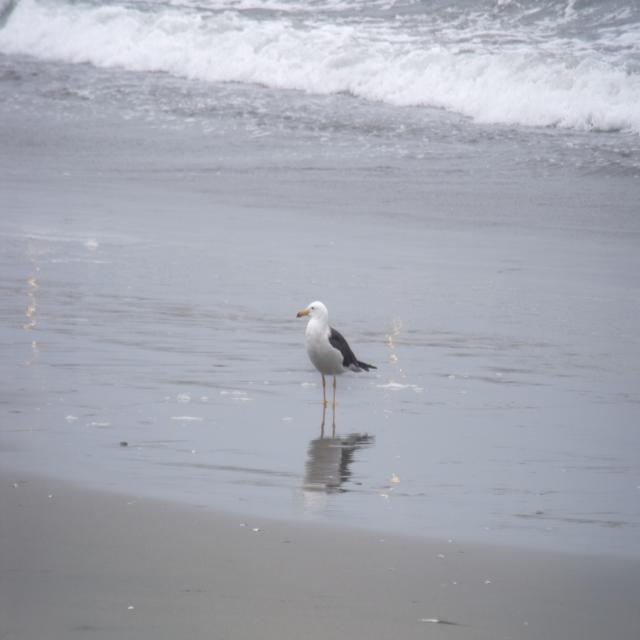

In [ ]:
res[20].show()